# El Farol Model
##### *"The Most Important Problem in Complex Systems Theory"* [John L. Casti](https://onlinelibrary.wiley.com/doi/abs/10.1002/cplx.6130010503)

#### **El Farol details**
So we have *N* agents each having *M* memory previous attendance values stored in a list. Each strategy consists of linear combination of the first element, a constant *c*, and then the weights (w<sub>i</sub>) for each of the previous attendance values A(t) (the number of w<sub>i</sub>*A(t) elements is determined by the memory *M*). The prediction of the next bar attendance p(t<sub>n</sub>) is calculated as:

\begin{equation}
p(t) = N*c + \sum_{i=1}^{M} w_{i} * A(t-i)
\end{equation}

So lets say we have N = 100 agent, and a memory of M = 2, with constant c = 0.3, and weights w<sub>1</sub> = -0.4 and w<sub>2</sub> = 0.3. If the previous attendance values were A(t-1) = 60 and A(t-2) = 80, then the prediction would be:

\begin{equation}
p(t) = 100(0.3) + (-0.4)(60) + (0.3)(80) = 30 - 24 + 24 = 30
\end{equation}

Note that c, w₁, and w₂ are all randomly generated between -1 and 1. The constant c is scaled by N to represent a baseline prediction in the absence of historical data (i.e., an agent's prior belief about typical bar attendance).

Importantly the weights are randomly generated when the strategies are created (w<sub>i</sub> ∈ [-1,1]); i.e., weights are between -1 and 1). So this means for a particular agent they may tend to weigh the last bar visit (w<sub>1</sub>) negatively (i.e. if the last bar visit was high attendance, they predict the next will be low attendance) or positively (if the last bar visit was high attendance, they predict the next will also be high attendance). Then the weight (w<sub>2</sub>) two visits back may have different weights (e.g., they may think the last visit was more important than the one before it). By random weighting we can capture a variety of prediction strategies.

#### The adaptive nature of El Farol
Another important thing about El Farol is that agents have *K* number of (random) strategies (S) that they can choose from, depending on which strategy has been most succesful in predict the past attendance. **This is the adaptive nature of El Farol.** After each round, agents update the scores of their strategies based on how well they predicted the actual attendance. The strategy S*(t) that has the lowest prediction error is then chosen for the next prediction.

\begin{equation}
S^*(t) = \argmin_{s \in S} |p_s(t)-A(t)|
\end{equation}

**This then this best stategy used for the next prediction p(t).**

With the best strategy the agent then decides whether to indeed attend the bar or not, based on whether their prediction is above or below the overcrowdingthreshold (e.g., 60). If their prediction is below the threshold they will attend, otherwise they will stay home.

\begin{equation}
Attend = \begin{cases} 
      True & \text{if } p(t) < \text{threshold} \\
      False & \text{if } p(t) \geq \text{threshold} 
   \end{cases}
\end{equation}

So this is quite complex... Remember we have the following components:
* Threshold
* Memory
* Number of strategies
* Number of agents
* Number of time steps

# Lets get started

For this practicum we want to be able to inspect a complex model setup, and do experiments with it. 

In [24]:
import mesa
from mesa.discrete_space import OrthogonalMooreGrid, CellAgent
from mesa.visualization import SolaraViz, make_plot_component, make_space_component
import solara
import numpy as np
import matplotlib.pyplot as plt

# Agent setup


In [25]:
# Set agent up
class BarGoingAgent(CellAgent):
    """An agent that decides whether to attend a bar based on strategies and memory.
    memory_size: number of previous bar visits that the agent weighs in its prediction
    number_of_strategies: number of strategies the agent holds
    overcrowding_threshold: threshold of attendance above which the bar is considered overcrowded
    """
    def __init__(self, model, cell,  N, memory_size=1,number_of_strategies=1, overcrowding_threshold=30):
        """Initialize the agent."""
        super().__init__(model)
        self.cell = cell
        self.N = N
        self.memory_size = memory_size
        self.number_of_strategies = number_of_strategies
        self.overcrowding_threshold = overcrowding_threshold

        # Add further agent attributes
        self.strategies = []
        self.attend = False     # plans to attend the bar? Initially no
        self.prediction = 0     # current prediction of the bar attendance (we think its empty at start)

        # Give the agent some random strategies
        self.generate_strategies()
            # index of the best strategy
        self.best_strategy = 0 # we set the first strategy as the best one for now
        self.prediction_error = 0
    
    def generate_strategies(self):
        """Generate random strategies for this agent."""
        # Each strategy is a list of weights from -1.0 to 1.0
        # The first weight is a constant, the rest are weights for previous time periods
        self.strategies = []
        for _ in range(self.number_of_strategies):
            strategy = []
            # Generate memory_size + weights + 1 (!constant! + memory weights)
            for _ in range(self.memory_size + 1):
                weight = 1.0 - (self.model.random.random() * 2.0)  # Random float from -1.0 to 1.0
                strategy.append(weight)
            self.strategies.append(strategy)

    def predict_attendance(self, strategy_index, attendance_history):
        """
        Predict attendance using a specific strategy and history subset.
        """
        strategy = self.strategies[strategy_index]
        # Start with the constant
        prediction = self.N * strategy[0]
        # Add weighted sum of weights and the attendance history
        for i, attendance in enumerate(attendance_history):
            if i + 1 < len(strategy):  # Check if there is a weight (i.e., has this memory)
                prediction += strategy[i + 1] * attendance
                
        return prediction

    def make_decision(self):
        """
        Decide whether to attend bar based on prediction.
        """
        # Step: Get recent history for prediction
        complete_history = self.model.history
        if len(complete_history) >= self.memory_size:
            attendance_history = complete_history[:self.memory_size]
        else:
            attendance_history = complete_history + [0]*(self.memory_size-len(complete_history))
        
        # Predict attendance using best strategy
        self.prediction = self.predict_attendance(self.best_strategy, attendance_history)
        # Decide to attend if prediction is below threshold
        self.attend = (self.prediction <= self.overcrowding_threshold)

    def get_zone(self):
        return self.model.zones.get(self.cell.coordinate, "unknown") # get zone name or otherwise return "unknown"
    
    def move_to_zone(self, zonetogo):
        """Move the agent to a random cell in the specified zone."""
        # Find all cells that belong to the target zone
        zone_cells = []
        if zonetogo == "bar":
            zone_cells = self.model.barcells
        elif zonetogo == "home":
            zone_cells = self.model.homecells
        # Find empty cells first in the target zone
        empty_cells = [cell for cell in zone_cells if len(cell.agents) == 0]
        # pick a random empty cell, or least crowded cell (if our bar is too small)
        if empty_cells:
            new_cell = self.model.random.choice(empty_cells)
            self.cell = new_cell
            return True
        else:
            # If no empty cells, move to least crowded
            least_crowded = min(zone_cells, key=lambda cell: len(cell.agents))
            self.cell = least_crowded
            return True
    
    def update_strategies(self):
        """
        Update which strategy is currently best.
        """
        history = self.model.history
        if len(history) < self.memory_size + 1:
            return  # Stop if not enough history
        
        current_lowest_error = float('inf')  # Start with maximum possible error
        
        # STest each strategy
        for strategy_idx in range(len(self.strategies)):
            error = 0
            # Step 4b: Test strategy performance over memory period
            for week in range(1, self.memory_size + 1):
                # Get history subset for this week
                if week + self.memory_size <= len(history):
                    history_subset = history[week:week + self.memory_size]
                    # Predict what attendance would have been
                    prediction = self.predict_attendance(strategy_idx, history_subset)
                    # Compare with actual attendance and add to score
                    actual_attendance = history[week - 1]
                    error += abs(actual_attendance - prediction)
            
            # Step 4c: Update best strategy if this one performed better
            if error <= current_lowest_error:
                current_lowest_error = error
                self.best_strategy = strategy_idx
                
        return current_lowest_error/self.memory_size  # return average prediction error
    
    def adapt_decide_move(self):
        """The key behavior method: adapt strategies, predict and decide attendance, move."""
        # Update strategies based on past performance
        self.prediction_error = self.update_strategies()
        # Make attendance decision based on prediction
        self.make_decision()
        # Move to appropriate zone based on decision
        if self.attend: # if true, 
            self.move_to_zone("bar")
        else:
            self.move_to_zone("home")

# Model setup

In [26]:
# some data collecting functions
def count_agents_in_bar(model):
    """Count the number of agents in the bar zone."""
    count = 0
    for cell in model.grid.all_cells.cells:
        if model.zones.get(cell.coordinate) == "bar":
            count += len(cell.agents)
    return count

class ElfarolModel(mesa.Model):
    """A model with a grid of cells and agents that can occupy them."""
    def __init__(self, N=100, width=20, height=20, seed=None, memory_size=5, 
                 number_of_strategies=10, overcrowding_threshold=60):
        """Initialize the model instance"""
        super().__init__(seed=seed)
        self.num_agents = N
        self.width = width
        self.height = height
        self.memory_size = memory_size
        self.number_of_strategies = number_of_strategies
        self.overcrowding_threshold = overcrowding_threshold
        self.grid = OrthogonalMooreGrid((width, height), torus=False, random=self.random)
        

        # Initialize history with random values (similar to the NetLogo)
        history_length = self.memory_size * 2  # Twice memory size for enough data
        self.history = [self.random.randint(0, 99) for _ in range(history_length)]
        # Initialize attendance and crowded status
        self.attendance = 0  # Current attendance
        self.is_crowded = False

        # Create home/bar zone mapping for tracking
        self.zones = {}
        self.barcells = []
        self.homecells = []
        for cell in self.grid.all_cells.cells:
            x, y = cell.coordinate
            # Define bar area (top-right quadrant)
            if x >= width//2 and y >= height//2:
                self.zones[(x, y)] = "bar"
                self.barcells.append(cell)
            else:
                self.zones[(x, y)] = "home"
                self.homecells.append(cell)

        # Create bar-going agents
        BarGoingAgent.create_agents(
            self,
            self.num_agents, 
            self.random.choices(self.grid.all_cells.cells, k=self.num_agents),
            memory_size=memory_size,
            number_of_strategies=number_of_strategies,
            overcrowding_threshold=overcrowding_threshold,
            N=self.num_agents
        )

        # Data collection setup
        self.datacollector = mesa.DataCollector(
            model_reporters={
                "agents_in_bar": count_agents_in_bar,
                "attendance": lambda m: m.attendance,
                "is_crowded": lambda m: m.is_crowded
            },
            agent_reporters={
                "zone": "get_zone",
                "prediction": "prediction",
                "attend": "attend",
                "prediction_error": "prediction_error"
            }
        )
        self.datacollector.collect(self)

    def step(self):
        """Model step - coordinates all agents."""
        # Reset crowded status
        self.is_crowded = False
        
        # Each agent does their own step (update strategies, decide, move)
        self.agents.shuffle_do("adapt_decide_move")
        
        # Count actual attendance
        self.attendance = count_agents_in_bar(self)
        
        # Check if crowded
        if self.attendance > self.overcrowding_threshold:
            self.is_crowded = True
        
        # Update history (by adding current attendance at the front and removing oldest)
        self.history = [self.attendance] + self.history[:-1]
        
        # Collect data
        self.datacollector.collect(self)

# Make a custom visualization so that we can represent the bar and home zones

In [27]:
# use Rectangle to draw background zones using patches
from matplotlib.patches import Rectangle

@solara.component
def CustomSpaceVisualization(model):
    """Custom space visualization with colored background zones"""
    # This is required to update the visualization when the model steps
    from mesa.visualization.components.matplotlib_components import update_counter
    update_counter.get()  # This triggers re-rendering on model updates
    # Setup figure
    fig = plt.Figure(figsize=(8, 8))    # Note: you must initialize a figure using this method instead of
    ax = fig.subplots()
    # set the width and height based on model
    width, height = model.width, model.height
    # Draw home area (light blue background)
    home_patch = Rectangle((0, 0), width, height, 
                          linewidth=0, facecolor='lightblue', alpha=0.3)
    ax.add_patch(home_patch)
    # Draw bar area (light coral background) - top-right quadrant
    bar_patch = Rectangle((width//2, height//2), width//2, height//2,
                         linewidth=0, facecolor='lightcoral', alpha=0.2)
    ax.add_patch(bar_patch)

    # load image for the background of the bar patch
    img = plt.imread("barbackground.png")
    ax.imshow(img, extent=[width//2, width, height//2, height], zorder=1, alpha=0.5, aspect='auto')
    # plot a label on the bar patch if crowded
    if model.is_crowded:
        ax.text(width * 0.75, height * 0.75, "Crowded", fontsize=20, color='black', ha='center', va='center', zorder=2)
    # Draw agents on top
    bar_agents = model.agents_by_type[BarGoingAgent]
    
    for agent in bar_agents:
        x, y = agent.cell.coordinate
        zone = agent.get_zone()
        
        if zone == "bar":
            color = "red"
            size = 100
        else:
            color = "blue"
            size = 80
            
        # Use matplotlib's OOP API instead of plt.scatter for thread safety
        ax.scatter(x + 0.5, y + 0.5, c=color, s=size, zorder=10, alpha=0.8)
    
    # Set up the plot
    ax.set_xlim(0, width)
    ax.set_ylim(0, height)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title('El Farol Model - Red Area=Bar, Blue Area=Home')
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    
    # This is required to render the visualization
    solara.FigureMatplotlib(fig)

### Set up the sliders for the model parameters


In [28]:
# add sliders
model_params = {
    "memory_size": {
        "type": "SliderInt",
        "value": 5,
        "label": "Memory size:",
        "min": 1,
        "max": 10,
        "step": 1,
    },
    "number_of_strategies": {
        "type": "SliderInt",
        "value": 10,
        "label": "Number of strategies:",
        "min": 1,
        "max": 20,
        "step": 1,
    },
    "overcrowding_threshold": {
        "type": "SliderInt",
        "value": 60,
        "label": "Overcrowding threshold:",
        "min": 10,
        "max": 100,
        "step": 1,
    }
}

In [29]:
model = ElfarolModel(width=20, height=20)

# Create visualization with custom component
page = SolaraViz(
    model,
    components=[CustomSpaceVisualization, make_plot_component("agents_in_bar")], # source code for plot components https://mesa.readthedocs.io/latest/_modules/mesa/visualization/components/matplotlib_components.html
    name="El Farol Model",
    model_params=model_params
)

# To run the visualization, uncomment the next line:
page

Cannot show ipywidgets in text

In [30]:
# Saving the animation to a gif

In [31]:
import pandas as pd
params = {"number_of_strategies": [1, 5, 10, 20],
          "memory_size": [1, 5, 10, 20]}

results_5seeds = mesa.batch_run(
    ElfarolModel,
    parameters=params,
    iterations=2, # we now explicitly set seeds to run through
    max_steps=50,
    number_processes=1,
    data_collection_period=1,  # Need to collect every step
    display_progress=True,
)

results_5seeds = pd.DataFrame(results_5seeds)
results_5seeds.to_csv('./batch_run_5seeds.csv')

  0%|          | 0/32 [00:00<?, ?it/s]

# plotting

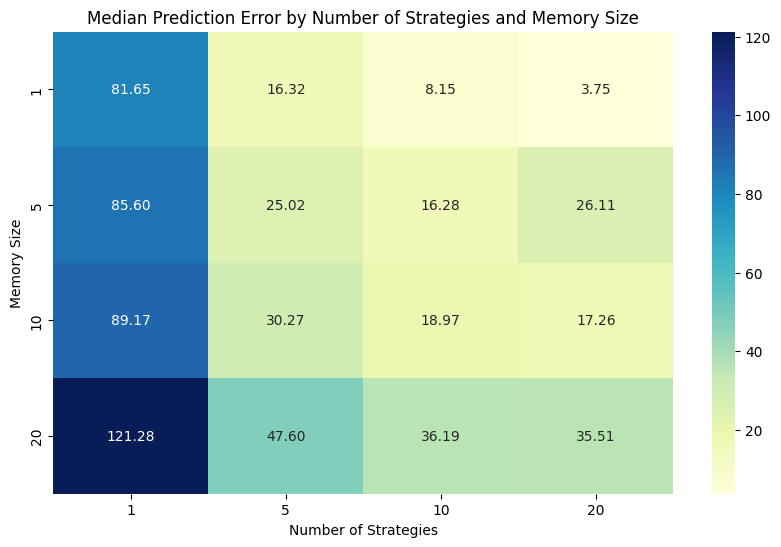

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
results_grouped = results_5seeds.groupby(['number_of_strategies', 'memory_size'])
median_errors = results_grouped['prediction_error'].median().reset_index()
plt.figure(figsize=(10, 6))
sns.heatmap(median_errors.pivot(index='memory_size', columns='number_of_strategies', values='prediction_error'), annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Median Prediction Error by Number of Strategies and Memory Size')
plt.xlabel('Number of Strategies')
plt.ylabel('Memory Size')
plt.savefig('median_prediction_error_heatmap.png') # save the figure
plt.show()